# Benchmark Run + Plot + Summary Notebook

This notebook provides an end-to-end benchmark workflow:
1. Build a benchmark name/path map from `examples/*.transact`
2. Run each benchmark using `cargo run -- {benchmark_path} {output_dir}`
3. Load generated JSON output from the selected output directory
4. Plot:
   - Cactus plot (sorted solved times, log-scale Y)
   - Strip plot (per-benchmark time distributions, single-point benchmarks supported)
5. Print a summary table similar to `benchmark_analysis.ipynb`

In [1]:
import json
import subprocess
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------- User-configurable paths --------
PROJECT_ROOT = Path('.').resolve()
EXAMPLES_DIRS = [PROJECT_ROOT / 'examples', PROJECT_ROOT / 'examples' / 'benchbase-transact']  # Add more example directories as needed
OUTPUT_ROOT = PROJECT_ROOT / 'tmp_plot'   # Change this to any other output root

# Build benchmark map from all transact files in examples/
BENCHMARK_MAP = {
    p.stem: str(p)
    for p in sorted([file for directory in EXAMPLES_DIRS for file in directory.glob('*.transact')])
}

# Special benchmark entry: include TPCC non-split dataset in later analysis loading.
# This path is JSON-only and does not need to be runnable by cargo.
BENCHMARK_MAP['TPC-C no split'] = str(PROJECT_ROOT / 'data_out_backup_out' / 'tpcc_out' / '61920' / 'data.json')

if not BENCHMARK_MAP:
    raise FileNotFoundError(f'No benchmark files found in {EXAMPLES_DIRS}')

print(f'Project root: {PROJECT_ROOT}')
print(f'Examples dir:  {EXAMPLES_DIRS}')
print(f'Output root:   {OUTPUT_ROOT}')
print('\nBenchmark map (name -> path):')
for name, path in BENCHMARK_MAP.items():
    print(f'  {name:20s} -> {path}')

Project root: /scratch/yanjunc6/FMitF_rs
Examples dir:  [PosixPath('/scratch/yanjunc6/FMitF_rs/examples'), PosixPath('/scratch/yanjunc6/FMitF_rs/examples/benchbase-transact')]
Output root:   /scratch/yanjunc6/FMitF_rs/tmp_plot

Benchmark map (name -> path):
  auctionmark          -> /scratch/yanjunc6/FMitF_rs/examples/benchbase-transact/auctionmark.transact
  epinions             -> /scratch/yanjunc6/FMitF_rs/examples/benchbase-transact/epinions.transact
  resourcestresser     -> /scratch/yanjunc6/FMitF_rs/examples/benchbase-transact/resourcestresser.transact
  sibench              -> /scratch/yanjunc6/FMitF_rs/examples/benchbase-transact/sibench.transact
  smallbank            -> /scratch/yanjunc6/FMitF_rs/examples/benchbase-transact/smallbank.transact
  tatp                 -> /scratch/yanjunc6/FMitF_rs/examples/benchbase-transact/tatp.transact
  tpcds                -> /scratch/yanjunc6/FMitF_rs/examples/benchbase-transact/tpcds.transact
  tpch                 -> /scratch/yanjunc6/F

In [2]:
# Set to True to execute benchmarks; set to False to reuse already generated outputs
RUN_BENCHMARKS = True

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
run_results = []

if RUN_BENCHMARKS:
    for bench_name, bench_path in BENCHMARK_MAP.items():
        # Skip JSON-only benchmarks that are added for analysis comparison.
        if bench_name == 'TPC-C no split' or str(bench_path).endswith('.json'):
            print(f"Skipping cargo run for JSON-only benchmark: {bench_name}")
            continue

        bench_output_dir = OUTPUT_ROOT / bench_name
        bench_output_dir.mkdir(parents=True, exist_ok=True)

        cmd = ['cargo', 'run', '--', bench_path, str(bench_output_dir)]
        print('\nRunning:', ' '.join(cmd))

        start = time.time()
        completed = subprocess.run(cmd, cwd=PROJECT_ROOT, capture_output=True, text=True)
        elapsed = time.time() - start

        run_results.append({
            'benchmark': bench_name,
            'return_code': completed.returncode,
            'elapsed_seconds': elapsed,
            'stdout_tail': '\n'.join(completed.stdout.splitlines()[-8:]),
            'stderr_tail': '\n'.join(completed.stderr.splitlines()[-8:]),
        })

        status = 'OK' if completed.returncode == 0 else 'FAIL'
        print(f'[{status}] {bench_name} finished in {elapsed:.2f}s')

    run_df = pd.DataFrame(run_results)
    print('\nRun summary:')
    display(run_df[['benchmark', 'return_code', 'elapsed_seconds']])
else:
    print('RUN_BENCHMARKS=False, skipping execution. Using existing outputs in OUTPUT_ROOT.')


Running: cargo run -- /scratch/yanjunc6/FMitF_rs/examples/benchbase-transact/auctionmark.transact /scratch/yanjunc6/FMitF_rs/tmp_plot/auctionmark
[OK] auctionmark finished in 10.95s

Running: cargo run -- /scratch/yanjunc6/FMitF_rs/examples/benchbase-transact/epinions.transact /scratch/yanjunc6/FMitF_rs/tmp_plot/epinions
[OK] epinions finished in 2.37s

Running: cargo run -- /scratch/yanjunc6/FMitF_rs/examples/benchbase-transact/resourcestresser.transact /scratch/yanjunc6/FMitF_rs/tmp_plot/resourcestresser
[OK] resourcestresser finished in 4.63s

Running: cargo run -- /scratch/yanjunc6/FMitF_rs/examples/benchbase-transact/sibench.transact /scratch/yanjunc6/FMitF_rs/tmp_plot/sibench
[OK] sibench finished in 0.91s

Running: cargo run -- /scratch/yanjunc6/FMitF_rs/examples/benchbase-transact/smallbank.transact /scratch/yanjunc6/FMitF_rs/tmp_plot/smallbank
[OK] smallbank finished in 4.26s

Running: cargo run -- /scratch/yanjunc6/FMitF_rs/examples/benchbase-transact/tatp.transact /scratch/

,benchmark,return_code,elapsed_seconds
0,auctionmark,0,10.951749
1,epinions,0,2.367192
2,resourcestresser,0,4.630633
3,sibench,0,0.912584
4,smallbank,0,4.257057
5,tatp,0,2.574185
6,tpcds,0,0.801635
7,tpch,0,1.022753
8,twitter,0,0.943600
9,voter,0,0.906871


In [3]:
def find_data_json(benchmark_output_dir: Path):
    """Find data.json directly or recursively under a benchmark output folder."""
    direct = benchmark_output_dir / 'data.json'
    if direct.exists():
        return direct

    matches = sorted(benchmark_output_dir.glob('**/data.json'))
    return matches[0] if matches else None

datasets = {}
missing = []

# Special JSON-only benchmark path requested by user
special_json_paths = {
    'TPC-C no split': PROJECT_ROOT / 'data_out_backup_out' / 'tpcc_out' / '61920' / 'data.json',
}

for bench_name in BENCHMARK_MAP:
    # Step-local replacement rule: use ycsb_null JSON as dataset 'ycsb' and ignore original ycsb.
    if bench_name == 'ycsb':
        continue

    effective_name = 'ycsb' if bench_name == 'ycsb_null' else bench_name

    if bench_name in special_json_paths:
        json_path = special_json_paths[bench_name]
    elif bench_name == 'TPC-C no split' and str(BENCHMARK_MAP[bench_name]).endswith('.json'):
        json_path = Path(BENCHMARK_MAP[bench_name])
    else:
        bench_output_dir = OUTPUT_ROOT / bench_name
        json_path = find_data_json(bench_output_dir)

    if json_path is None or not Path(json_path).exists():
        missing.append((effective_name, str(json_path) if json_path is not None else str(OUTPUT_ROOT / bench_name)))
        continue

    with open(json_path, 'r') as f:
        datasets[effective_name] = json.load(f)

print('Loaded JSON datasets:')
for name in sorted(datasets):
    print(f'  {name}')

if missing:
    print('\nMissing data.json for:')
    for name, path_or_dir in missing:
        print(f'  {name:20s} (searched in {path_or_dir})')

if not datasets:
    raise RuntimeError('No datasets loaded. Run benchmarks first or check OUTPUT_ROOT.')

Loaded JSON datasets:
  TPC-C no split
  auctionmark
  epinions
  resourcestresser
  rubis
  sibench
  smallbank
  social
  tatp
  tpcc
  twitter
  voter
  wikipedia
  ycsb

Missing data.json for:
  tpcds                (searched in /scratch/yanjunc6/FMitF_rs/tmp_plot/tpcds)
  tpch                 (searched in /scratch/yanjunc6/FMitF_rs/tmp_plot/tpch)


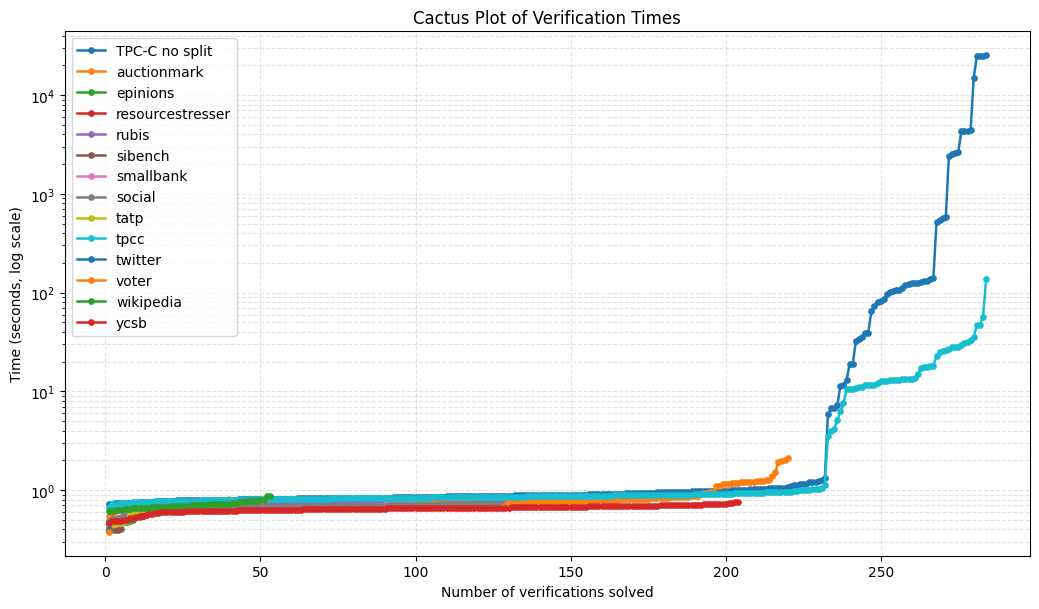

In [4]:
def extract_durations_seconds(data):
    verifications = data.get('c_edge_verifications', [])
    return [float(v['duration_ms']) / 1000.0 for v in verifications if 'duration_ms' in v]

durations_by_benchmark = {
    name: extract_durations_seconds(data)
    for name, data in datasets.items()
}

# Optional combined cactus line over all benchmarks
SHOW_COMBINED_CACTUS = False

# Cactus styling: show dots along each benchmark line
CACTUS_MARKER = 'o'
CACTUS_MARKER_SIZE = 3.8

plt.figure(figsize=(10.5, 6.2))
for name in sorted(durations_by_benchmark):
    times = np.array(sorted(durations_by_benchmark[name]), dtype=float)
    if len(times) == 0:
        continue
    solved = np.arange(1, len(times) + 1)
    plt.plot(
        solved,
        times,
        linewidth=1.8,
        marker=CACTUS_MARKER,
        markersize=CACTUS_MARKER_SIZE,
        label=name,
    )

if SHOW_COMBINED_CACTUS:
    combined = []
    for times in durations_by_benchmark.values():
        combined.extend(times)
    combined = np.array(sorted(combined), dtype=float)
    if len(combined) > 0:
        solved = np.arange(1, len(combined) + 1)
        plt.plot(
            solved,
            combined,
            linestyle='--',
            linewidth=2.3,
            marker=CACTUS_MARKER,
            markersize=CACTUS_MARKER_SIZE,
            color='black',
            label='ALL (combined)',
        )

plt.yscale('log')
plt.xlabel('Number of verifications solved')
plt.ylabel('Time (seconds, log scale)')
plt.title('Cactus Plot of Verification Times')
plt.grid(True, which='both', linestyle='--', alpha=0.35)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'cactus_plot.pdf')
plt.show()

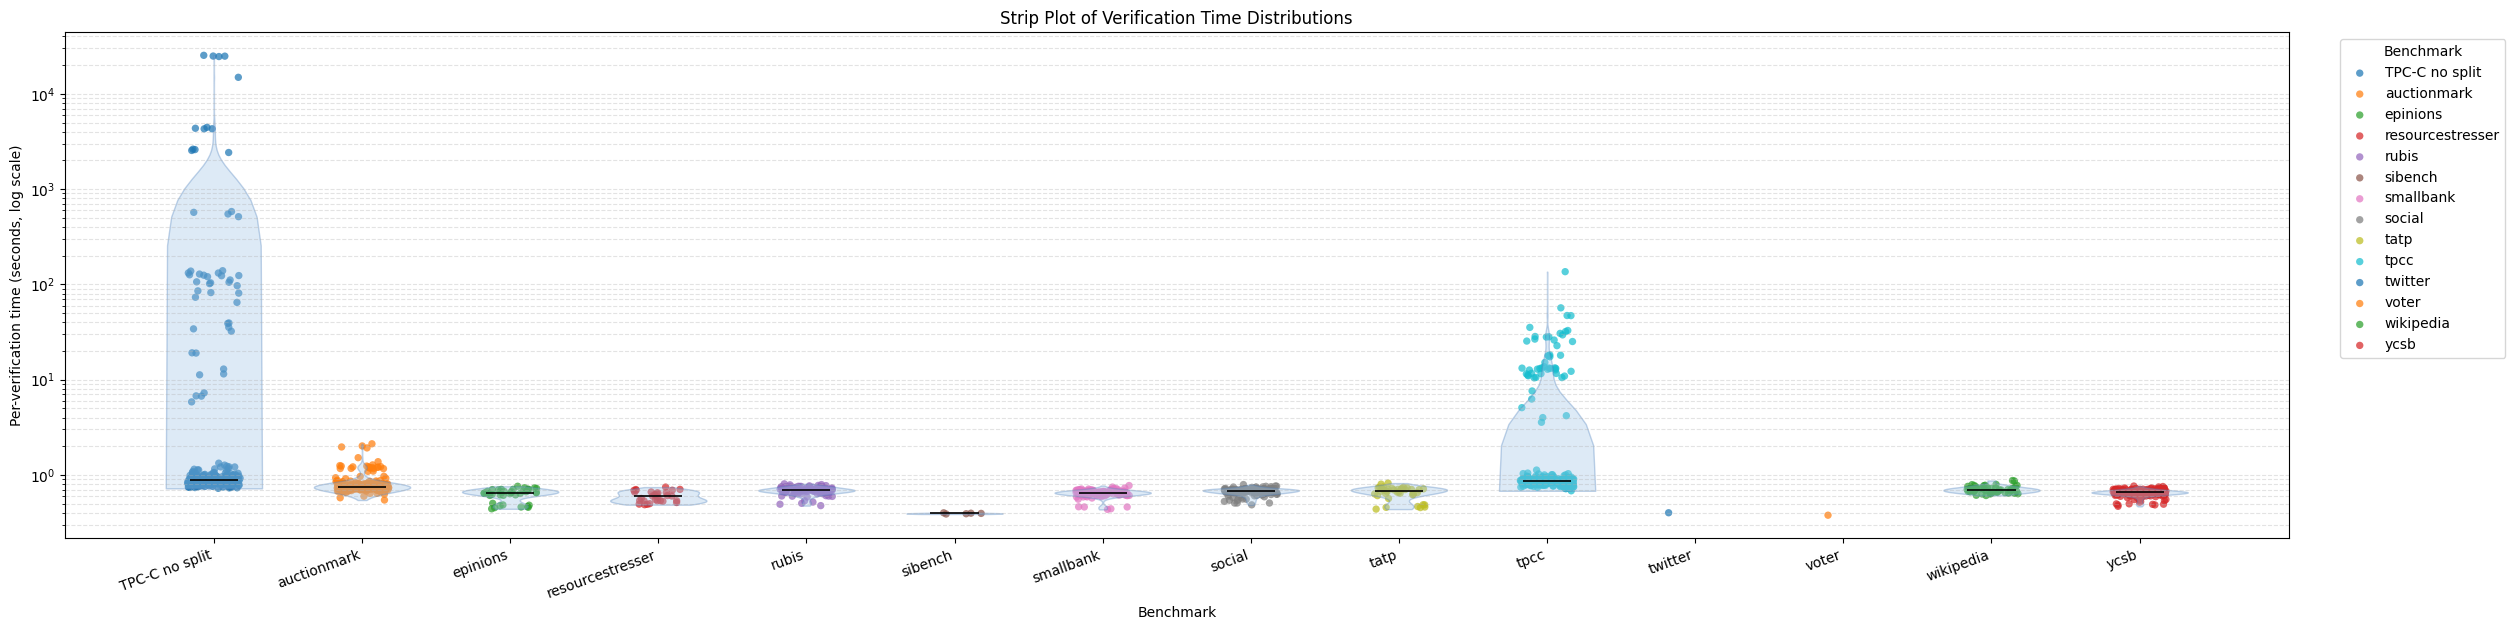

In [5]:
# Strip plot (manual jittered scatter), robust even when a benchmark has only one point
benchmarks = sorted(durations_by_benchmark.keys())
rng = np.random.default_rng(42)

# Overlay options: 'none', 'box', 'violin'
OVERLAY_MODE = 'violin'
SHOW_POINTS = True

fig, ax = plt.subplots(figsize=(max(10, 1.8 * len(benchmarks)), 6.4))

overlay_positions = []
overlay_values = []

for i, bench in enumerate(benchmarks, start=1):
    times = np.array(durations_by_benchmark[bench], dtype=float)
    if len(times) == 0:
        continue

    if SHOW_POINTS:
        x_jitter = i + rng.uniform(-0.18, 0.18, size=len(times))
        ax.scatter(x_jitter, times, s=28, alpha=0.72, edgecolors='none', label=bench)

    # Keep only groups with >1 point for distribution overlays
    if len(times) > 1:
        overlay_positions.append(i)
        overlay_values.append(times)

if OVERLAY_MODE == 'box' and overlay_values:
    bp = ax.boxplot(
        overlay_values,
        positions=overlay_positions,
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        medianprops={'color': 'black', 'linewidth': 1.4},
    )
    for patch in bp['boxes']:
        patch.set_facecolor('#9fc5e8')
        patch.set_alpha(0.35)

elif OVERLAY_MODE == 'violin' and overlay_values:
    vp = ax.violinplot(
        overlay_values,
        positions=overlay_positions,
        widths=0.65,
        showmeans=False,
        showmedians=True,
        showextrema=False,
    )
    for body in vp['bodies']:
        body.set_facecolor('#9fc5e8')
        body.set_edgecolor('#4f81bd')
        body.set_alpha(0.35)
    if 'cmedians' in vp:
        vp['cmedians'].set_color('black')
        vp['cmedians'].set_linewidth(1.2)

ax.set_xticks(np.arange(1, len(benchmarks) + 1))
ax.set_xticklabels(benchmarks, rotation=20, ha='right')
ax.set_yscale('log')
ax.set_xlabel('Benchmark')
ax.set_ylabel('Per-verification time (seconds, log scale)')
ax.set_title('Strip Plot of Verification Time Distributions')
ax.grid(True, which='both', axis='y', linestyle='--', alpha=0.35)

# Avoid duplicate legend entries for points
if SHOW_POINTS:
    handles, labels = ax.get_legend_handles_labels()
    dedup = dict(zip(labels, handles))
    ax.legend(dedup.values(), dedup.keys(), title='Benchmark', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'strip_plot.pdf')
plt.show()

In [6]:
summary_rows = []

# Keep report names aligned with what is actually loaded in datasets.
report_benchmarks = sorted(datasets.keys())

for benchmark_name in report_benchmarks:
    data = datasets.get(benchmark_name)
    verifications = data.get('c_edge_verifications', []) if data is not None else []

    total_count = len(verifications)
    pass_count = sum(1 for v in verifications if v.get('result') == 'Pass')
    error_count = sum(1 for v in verifications if v.get('result') == 'Error')
    timeout_count = sum(1 for v in verifications if v.get('result') == 'Timeout')
    commutative_rate = (pass_count / total_count * 100.0) if total_count > 0 else 0.0

    if total_count > 0:
        durations = np.array([float(v['duration_ms']) / 1000.0 for v in verifications], dtype=float)
        total_time = float(np.sum(durations))
        median_time = float(np.median(durations))
        p95_time = float(np.percentile(durations, 95))
        max_time = float(np.max(durations))
    else:
        total_time = 0.0
        median_time = 0.0
        p95_time = 0.0
        max_time = 0.0

    summary_rows.append({
        'Benchmark': benchmark_name,
        'Total C-Edges': total_count,
        'Commutative (Pass)': pass_count,
        'Non-Commutative': error_count,
        'Timeouts': timeout_count,
        'Commutative Rate (%)': f'{commutative_rate:.1f}',
        'Total Time (s)': f'{total_time:.2f}',
        'Median Time (s)': f'{median_time:.4f}',
        'P95 Time (s)': f'{p95_time:.4f}',
        'Max Time (s)': f'{max_time:.4f}',
    })

summary_df = pd.DataFrame(summary_rows)[[
    'Benchmark',
    'Total C-Edges',
    'Commutative (Pass)',
    'Non-Commutative',
    'Timeouts',
    'Commutative Rate (%)',
    'Total Time (s)',
    'Median Time (s)',
    'P95 Time (s)',
    'Max Time (s)',
]]

print('\n' + '=' * 160)
print('BENCHMARK SUMMARY')
print('=' * 160)
print(summary_df.to_string(index=False))
print('=' * 160)

print('\nDetailed breakdown:\n')
for row in summary_rows:
    print(f"{row['Benchmark']}:")
    print(f"  Total C-edges:           {row['Total C-Edges']}")
    print(f"  Commutative (Pass):      {row['Commutative (Pass)']}")
    print(f"  Non-Commutative:         {row['Non-Commutative']}")
    print(f"  Timeouts:                {row['Timeouts']}")
    print(f"  Commutative Rate:        {row['Commutative Rate (%)']}%")
    print(f"  Total Time:              {row['Total Time (s)']} seconds")
    print(f"  Median Time:             {row['Median Time (s)']} seconds")
    print(f"  P95 Time:                {row['P95 Time (s)']} seconds")
    print(f"  Max Time:                {row['Max Time (s)']} seconds\n")


BENCHMARK SUMMARY
       Benchmark  Total C-Edges  Commutative (Pass)  Non-Commutative  Timeouts Commutative Rate (%) Total Time (s) Median Time (s) P95 Time (s) Max Time (s)
  TPC-C no split            284                 232               51         0                 81.7      147281.35          0.8894     567.0075   25364.3632
     auctionmark            220                  98              122         0                 44.5         179.26          0.7508       1.2177       2.1226
        epinions             40                   0               40         0                  0.0          24.98          0.6477       0.7320       0.7602
resourcestresser             29                   0               29         0                  0.0          17.31          0.6002       0.7040       0.7454
           rubis             91                  12               79         0                 13.2          62.17          0.6917       0.7702       0.8061
         sibench              5        